# Advanced Data Visualization and Storytelling with Python

## 1. Data Load 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## 2. Data Understanding and Cleaning

Before creating visualizations, the dataset was inspected for data types, missing values, duplicate records, and basic statistical properties. Date fields were converted into datetime format to support time-based analysis.

In [4]:
# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Check column information
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Check numerical summary
print("\nStatistical Summary:")
display(df.describe())

# Check unique categories
print("\nProduct Categories:")
print(df["product_category"].unique())

print("\nRegions:")
print(df["region"].unique())

print("\nPayment Methods:")
print(df["payment_method"].unique())

Dataset Shape: (5000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price 

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219



Product Categories:
<StringArray>
['Beauty', 'Clothing', 'Electronics', 'Home']
Length: 4, dtype: str

Regions:
<StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

Payment Methods:
<StringArray>
['Wallet', 'Card', 'COD']
Length: 3, dtype: str


In [5]:
# Create time-based features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")
df["day_name"] = df["order_date"].dt.day_name()

# Check result
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,month_name,day_name
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,Jan,Saturday
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,Jan,Sunday
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,Jan,Monday
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,Jan,Tuesday
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,Jan,Wednesday


## 3. Visualization 1: Revenue Trend Over Time

A time-series line chart is used to identify changes in revenue over the analysis period. This visualization helps a non-technical audience quickly understand whether business performance is increasing, decreasing, or fluctuating over time.

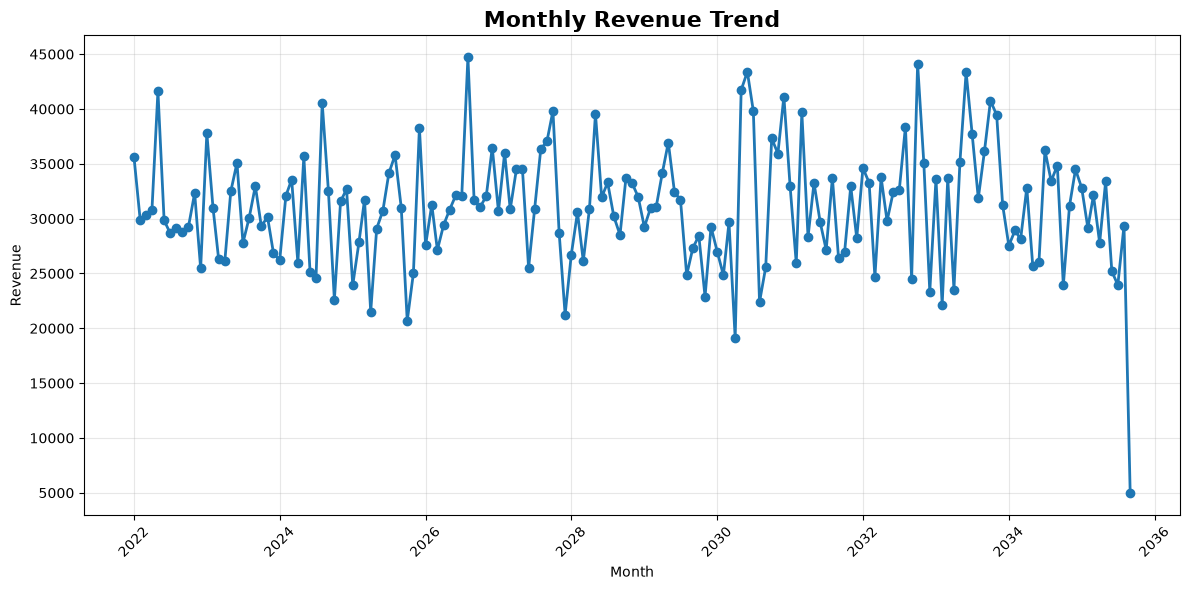

In [6]:
# Monthly revenue
monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["order_date"] = monthly_revenue["order_date"].dt.to_timestamp()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["revenue"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 4. Visualization 2: Revenue by Product Category

This visualization compares total revenue across product categories. It helps identify which categories contribute most strongly to overall business performance and where management may need to focus inventory, marketing, or promotional efforts.

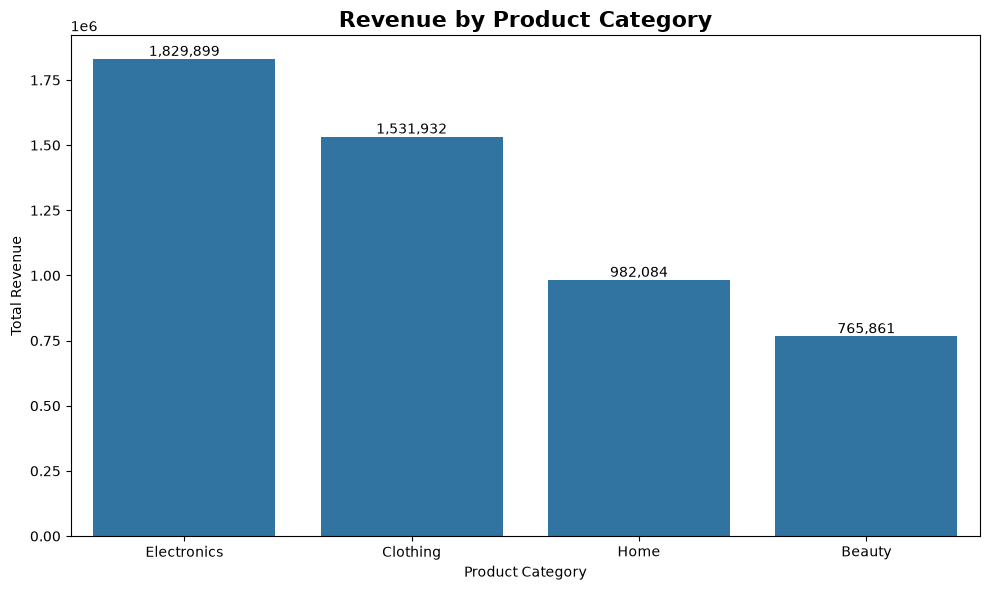

In [7]:
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title(
    "Revenue by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

# Add labels
for bar in bars.patches:
    bars.annotate(
        f"{bar.get_height():,.0f}",
        (bar.get_x() + bar.get_width() / 2,
         bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 5. Visualization 3: Revenue by Region

This visualization examines how revenue is distributed across geographical regions. Comparing regions helps identify strong and weak markets and supports decisions related to marketing, logistics, and regional expansion.

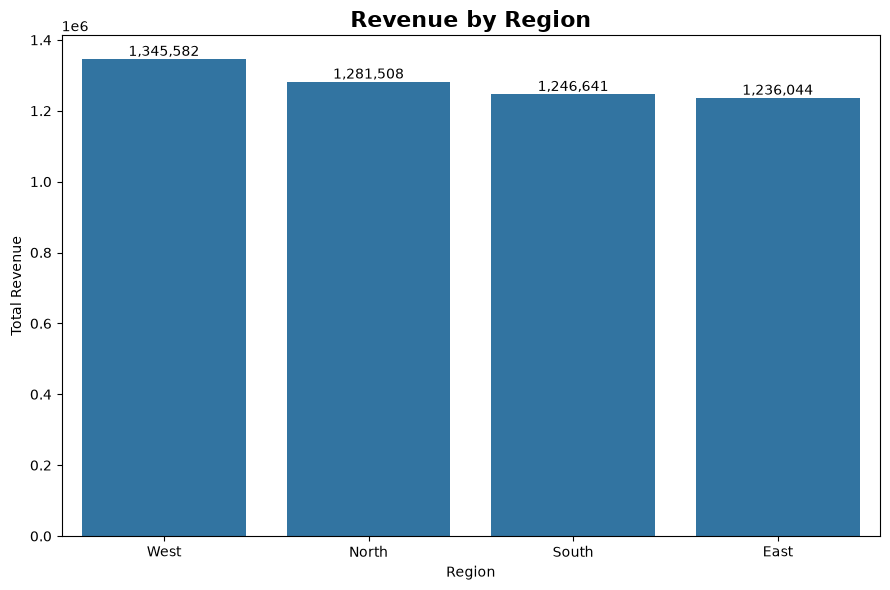

In [8]:
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

bars = sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title(
    "Revenue by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Revenue")

for bar in bars.patches:
    bars.annotate(
        f"{bar.get_height():,.0f}",
        (bar.get_x() + bar.get_width() / 2,
         bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 6. Visualization 4: Discount vs Revenue

A scatter plot is used to investigate whether higher discounts are associated with higher or lower revenue. Each point represents an individual order. This visualization helps identify patterns, clusters, and unusual observations that may not be visible in an aggregated chart.

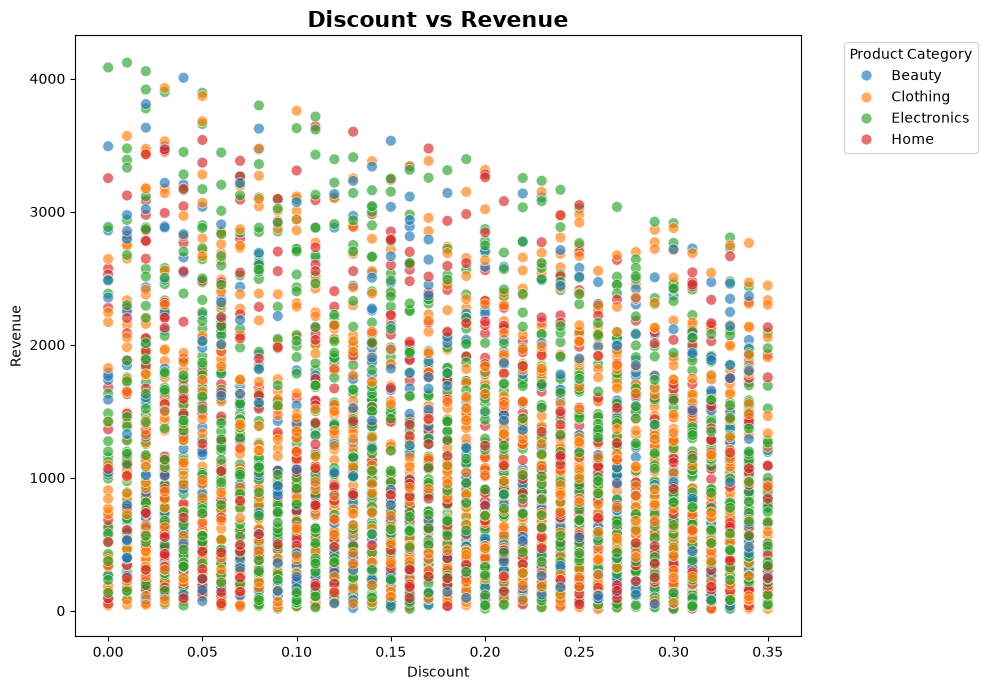

In [9]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="discount",
    y="revenue",
    hue="product_category",
    alpha=0.65,
    s=60
)

plt.title(
    "Discount vs Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Revenue")

plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 7. Visualization 5: Customer Rating vs Revenue

This visualization examines whether customer satisfaction, represented by customer ratings, is associated with revenue. Understanding this relationship can help businesses evaluate whether improving customer experience may be connected with stronger sales performance.

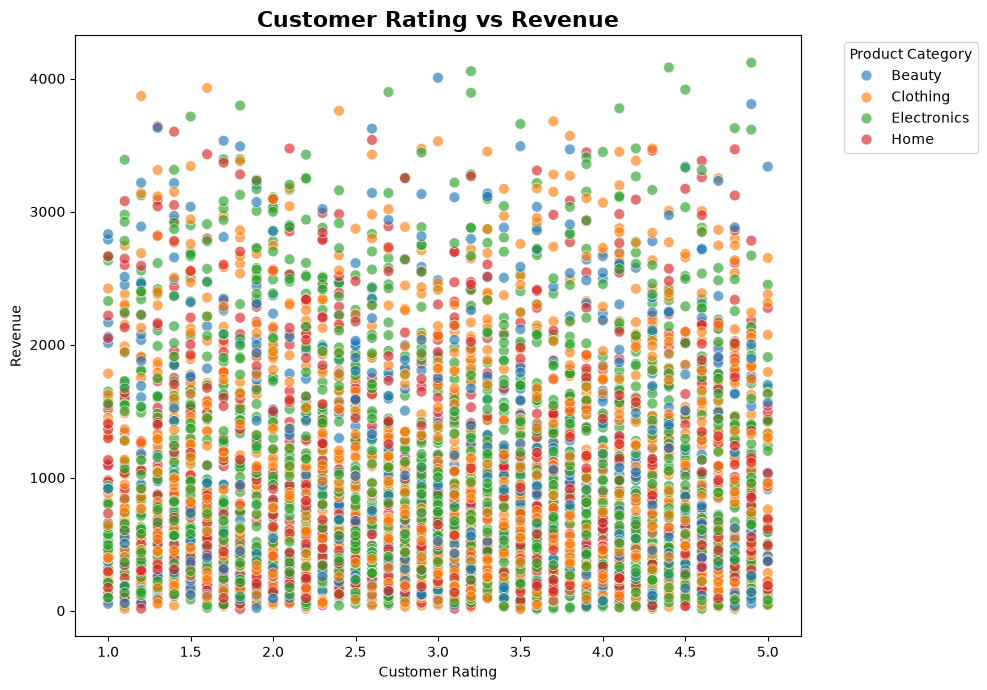

In [10]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="customer_rating",
    y="revenue",
    hue="product_category",
    alpha=0.65,
    s=60
)

plt.title(
    "Customer Rating vs Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Rating")
plt.ylabel("Revenue")

plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 8. Visualization 6: Monthly Revenue Heatmap

A heatmap is used to visualize revenue intensity across months and years. Darker or lighter areas make high- and low-performing periods easier to identify at a glance. This helps reveal seasonal patterns and unusual periods of business performance.

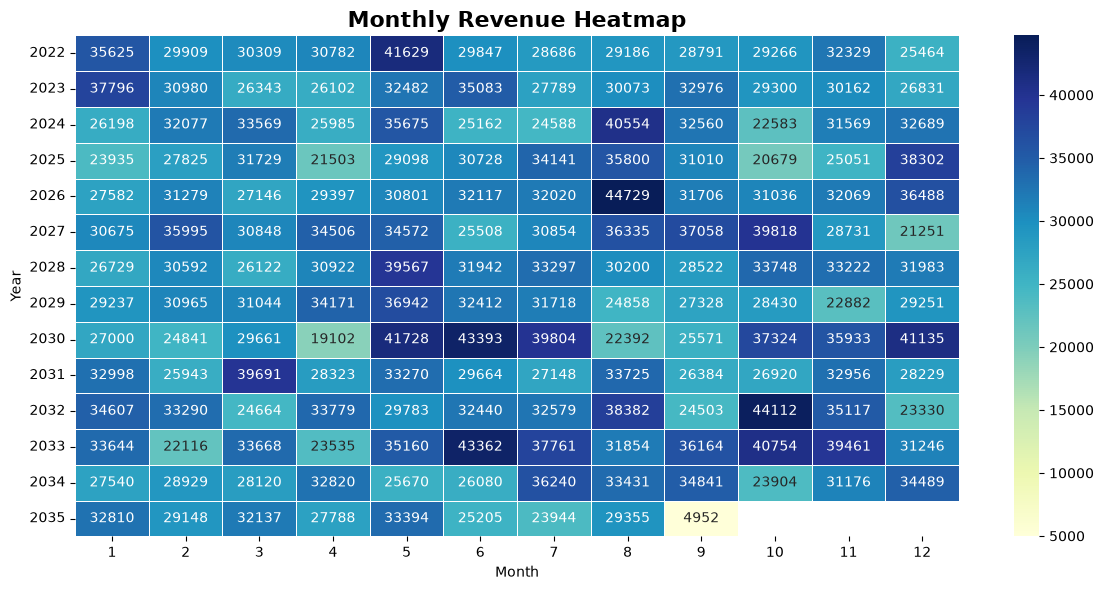

In [11]:
monthly_heatmap = df.pivot_table(
    index="year",
    columns="month",
    values="revenue",
    aggfunc="sum"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    monthly_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Monthly Revenue Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

## 9. Overall Data Story and Key Insights

The visual analysis provides a multi-dimensional view of e-commerce performance. Category-level and regional analysis identifies the major contributors to revenue, while the scatter plots explore relationships between revenue, discounts, and customer satisfaction. The monthly heatmap adds a time-based perspective and helps identify periods of stronger or weaker performance.

Together, these visualizations move from broad business performance to specific explanatory relationships. This storytelling approach makes the analysis easier for non-technical stakeholders to understand and provides a foundation for data-driven business decisions.

In [14]:
print("========== KEY BUSINESS METRICS ==========")

# Basic metrics
total_revenue = df["revenue"].sum()
average_revenue = df["revenue"].mean()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
average_rating = df["customer_rating"].mean()
average_discount = df["discount"].mean()

# Correlations
discount_revenue_corr = df["discount"].corr(df["revenue"])
rating_revenue_corr = df["customer_rating"].corr(df["revenue"])

# Print results
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Revenue per Order: {average_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Customer Rating: {average_rating:.2f}")
print(f"Average Discount: {average_discount:.2%}")

print("\nTop Product Category:")
print(category_revenue.idxmax())

print("\nTop Region:")
print(region_revenue.idxmax())

print("\nDiscount-Revenue Correlation:")
print(round(discount_revenue_corr, 3))

print("\nRating-Revenue Correlation:")
print(round(rating_revenue_corr, 3))

========== KEY BUSINESS METRICS ==========
Total Revenue: 5,109,775.74
Average Revenue per Order: 1,021.96
Total Orders: 5,000
Total Customers: 989
Average Customer Rating: 2.97
Average Discount: 18.00%

Top Product Category:
Electronics

Top Region:
West

Discount-Revenue Correlation:
-0.139

Rating-Revenue Correlation:
0.012


## 13. Business Implications

The analysis provides several useful insights for e-commerce business decision-making. The total revenue generated by the dataset is approximately 5.11 million, indicating a substantial level of commercial activity across 5,000 orders and 989 unique customers.

Electronics emerged as the highest-revenue product category. This suggests that the business should closely monitor demand, inventory availability, pricing, and promotional strategies within this category. Maintaining adequate stock of high-performing products can help reduce missed sales opportunities.

The West region generated the highest revenue among the analysed regions. This indicates that regional performance is not uniform and that customer demand may be concentrated in particular markets. Management could investigate the reasons for the West region's stronger performance, such as customer preferences, pricing, marketing campaigns, or delivery experience, and use successful strategies in weaker regions.

The average discount in the dataset was approximately 18%. Discounts can encourage purchases, but excessive discounting may reduce profitability. Therefore, discount strategies should be evaluated alongside revenue and customer behaviour rather than being increased automatically.

The customer rating average was approximately 2.97 out of 5. This relatively moderate rating suggests an opportunity to improve customer satisfaction. The business could investigate product quality, delivery performance, customer service, and return experiences to identify the main causes of lower ratings.

Overall, the visual analysis can support decisions related to inventory planning, regional marketing, pricing, promotional campaigns, and customer-experience improvement.

## 14. Limitations

This analysis has several limitations that should be considered when interpreting the findings.

First, the dataset contains 5,000 records and represents a particular e-commerce environment. Therefore, the results may not be directly generalizable to every e-commerce business or market.

Second, the analysis is primarily descriptive. The visualizations identify patterns and relationships but do not prove that one variable directly causes another. For example, a relationship between discount and revenue does not necessarily mean that discounts alone caused changes in revenue.

Third, the dataset does not provide detailed information about marketing expenditure, profit margins, customer demographics, product costs, or competitors. These additional variables could provide a deeper understanding of business performance.

Fourth, revenue is different from profit. A product or category generating high revenue may not necessarily be the most profitable if its costs or discounts are also high.

Finally, customer ratings provide an indication of customer satisfaction but may be influenced by several factors that are not directly available in the dataset. Further analysis would be required to identify the exact reasons behind customer ratings.

## 15. Conclusion

This project demonstrated how Python-based data visualization can transform an e-commerce dataset into an understandable business story. Using Pandas, Matplotlib, and Seaborn, the analysis examined revenue trends, product categories, regional performance, discount relationships, customer ratings, and monthly revenue patterns.

The dataset generated approximately 5.11 million in total revenue from 5,000 orders and 989 unique customers. Electronics was identified as the highest-revenue product category, while the West region was the strongest geographical market. The analysis also highlighted an average customer rating of 2.97 and an average discount of approximately 18%, providing potential areas for further business investigation.

The six visualizations were intentionally selected to communicate different aspects of the dataset. Line charts were used to communicate trends, bar charts to compare categories and regions, scatter plots to explore relationships, and a heatmap to reveal time-based patterns.

The project demonstrates that effective data storytelling is not simply about producing attractive charts. A strong visualization should answer a specific question, highlight an important pattern, and help stakeholders understand what the pattern may mean for decision-making.

Future analysis could extend this work through formal statistical hypothesis testing and machine-learning techniques. Such methods could validate the observed relationships and potentially predict customer behaviour or business outcomes.

## 16. Python Code / Reproducibility

The complete analysis was developed using Python in a Jupyter Notebook. The main libraries used were Pandas, NumPy, Matplotlib, Seaborn, and Plotly where required.

The dataset was loaded from a CSV file using Pandas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

The order date was converted into a datetime format to enable time-based analysis:

df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")
df["day_name"] = df["order_date"].dt.day_name()

Category-level revenue was calculated using:

category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

Regional revenue was calculated using:

region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

Relationships between numerical variables were examined using Pearson correlation:

discount_revenue_corr = df["discount"].corr(df["revenue"])

rating_revenue_corr = df["customer_rating"].corr(
    df["revenue"]
)

The visualizations were generated using Matplotlib and Seaborn. The notebook contains the complete executable workflow, including data loading, data preparation, exploratory analysis, visualization development, correlation analysis, and summary metrics.

The analysis can be reproduced by placing the dataset and Jupyter Notebook in the same project directory and executing the notebook cells sequentially.